In [2]:
from qaoa_old import * 
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
def max_cut_to_max_2_sat(graph):
    """
    Translate a graph representing a Max-Cut problem into a Max-2-SAT instance.

    Args:
    - graph (list of lists): The adjacency matrix representing the graph.

    Returns:
    - max_2_sat (list of tuples): The Max-2-SAT instance as a list of tuples representing clauses.
    """

    max_2_sat = []
    num_vertices = len(graph)

    # Create clauses for each edge
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if graph[i][j] == 1:
                # Convert vertex indices to values in the range 1 to n
                clause1 = (i + 1, j + 1)
                clause2 = (-(i + 1), -(j + 1))
                max_2_sat.append(clause1)
                max_2_sat.append(clause2)
                
    return max_2_sat

def H_sat_from_max_2_sat(max_2_sat_instance, n):
    """
    Constructs the Hamiltonian for k-SAT problems from a Max-2-SAT instance.

    Args:
    - max_2_sat_instance (list of tuples): Max-2-SAT instance as a list of tuples representing clauses.
    - n (int): Number of variables.

    Returns:
    - ndarray: Diagonal elements of the Hamiltonian for k-SAT.
    """
    I_prime = np.array([1, 1])
    rho_0_prime = np.array([1, 0])
    rho_1_prime = np.array([0, 1])

    h = np.zeros(2 ** n)

    for clause in max_2_sat_instance:
        # print(clause)
        if 1 == abs(clause[0]):  # Adjust index to start from 0
            if clause[0] > 0:
                clause_hamiltonian = rho_0_prime
            else:
                clause_hamiltonian =  rho_1_prime

        elif 1 == abs(clause[1]):  # Adjust index to start from 0
            if clause[1] > 0:
                clause_hamiltonian =  rho_0_prime
            else:
                clause_hamiltonian = rho_1_prime

        else:
            clause_hamiltonian =  I_prime

        # print(1, clause_hamiltonian)

        for var in range(2,n+1):

            if var == abs(clause[0]):  # Adjust index to start from 0
                if clause[0] > 0:
                    clause_hamiltonian = np.kron(clause_hamiltonian, rho_0_prime)
                else:
                    clause_hamiltonian = np.kron(clause_hamiltonian, rho_1_prime)

            elif var == abs(clause[1]):  # Adjust index to start from 0
                if clause[1] > 0:
                    clause_hamiltonian = np.kron(clause_hamiltonian, rho_0_prime)
                else:
                    clause_hamiltonian = np.kron(clause_hamiltonian, rho_1_prime)

            else:
                clause_hamiltonian = np.kron(clause_hamiltonian, I_prime)
            # print(var, clause_hamiltonian)
            # print(var, clause_hamiltonian, h)
        h += clause_hamiltonian

    return h

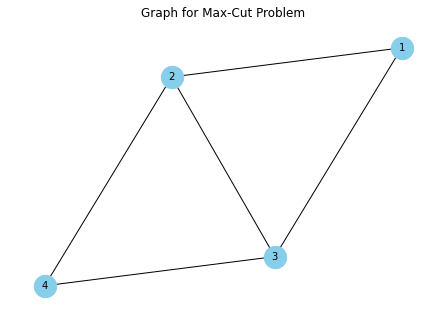

Max-2-SAT instance:
[(1, 2), (-1, -2), (1, 3), (-1, -3), (2, 3), (-2, -3), (2, 4), (-2, -4), (3, 4), (-3, -4)]


In [3]:

def plot_graph(graph):
    """
    Plot the graph using networkx and matplotlib.

    Args:
    - graph (list of lists): The adjacency matrix representing the graph.
    """

    G = nx.Graph()

    # Add nodes
    num_vertices = len(graph)
    for i in range(num_vertices):
        G.add_node(i + 1)

    # Add edges
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if graph[i][j] == 1:
                G.add_edge(i + 1, j + 1)

    # Plot graph
    pos = nx.spring_layout(G)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=10)
    plt.title("Graph for Max-Cut Problem")
    plt.show()

    # Example usage
graph = [
    [0, 1, 1, 0],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [0, 1, 1, 0]
]

max_2_sat_instance = max_cut_to_max_2_sat(graph)
plot_graph(graph)
print("Max-2-SAT instance:")
print(max_2_sat_instance)


In [4]:
hamiltonian = H_sat_from_max_2_sat(max_2_sat_instance, np.max(max_2_sat_instance))
print("Hamiltonian for Max-2-SAT instance:")
print(hamiltonian)

Hamiltonian for Max-2-SAT instance:
[5. 3. 2. 2. 2. 2. 1. 3. 3. 1. 2. 2. 2. 2. 3. 5.]


In [5]:
n = 4  # Number of nodes
d = 2  # Degree of each node
G = nx.random_regular_graph(d, n)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
adj_matrix

[[0, 1, 0, 1], [1, 0, 1, 0], [0, 1, 0, 1], [1, 0, 1, 0]]

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multiple_angles_on_circle(angles_list, alpha=0.1):
    """
    Plot optimal angles as dots on a circle for betas and gammas with different colors for multiple angle arrays.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.

    Returns:
    - None
    """
    num_betas = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    num_runs = len(angles_list)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_aspect('equal')

    radius = [0.5 + 0.2*i for i in range(num_betas)]
    for angles in angles_list:
        betas = angles[:num_betas]
        gammas = angles[num_betas:]
        for i, r in enumerate(radius):
            # Plot betas with reduced transparency
            ax.plot(betas[i], r, 'bo', markersize=8, alpha=alpha)

            # Plot gammas with reduced transparency
            ax.plot(gammas[i], r, 'ro', markersize=8, alpha=alpha)

    plt.title("Optimal Angles on Circle")
    ax.set_yticks([0.5 + 0.2*i for i in range(num_betas)])
    ax.set_yticklabels([i+1 for i in range(num_betas)])
    plt.show()


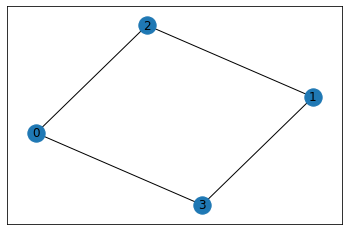

In [7]:
nx.draw_networkx(G)

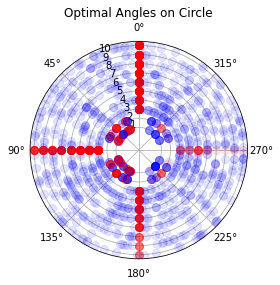

In [8]:
angles_list = []
for i in range(100):
    hamiltonian = Graph_to_Hamiltonian(adj_matrix)
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


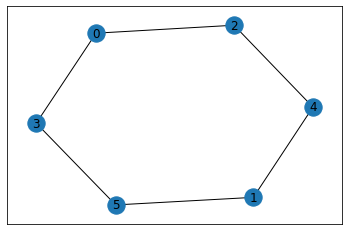

In [9]:
n = 6  # Number of nodes
d = 2  # Degree of each node
G = nx.random_regular_graph(d, n)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
nx.draw_networkx(G)

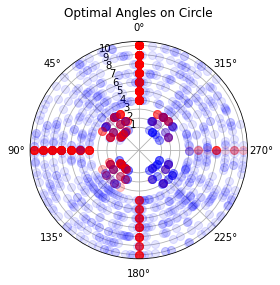

In [10]:
angles_list = []
for i in range(100):
    hamiltonian = Graph_to_Hamiltonian(adj_matrix)
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


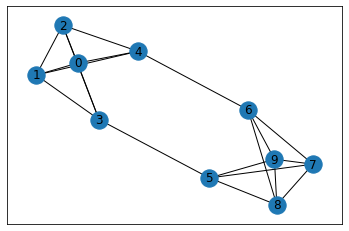

In [6]:
edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 4],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 2],
 [4, 6],
 [5, 3],
 [5, 7],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 5],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]

G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

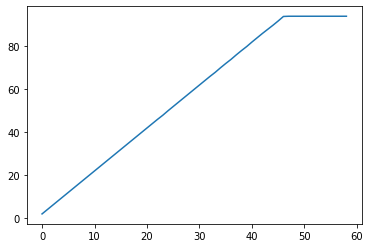

In [111]:
rank = []
for p in range(1,60):
    q = QAOA(p, hamiltonian)
    buf = 0
    for _ in range(10):
        buf += np.linalg.matrix_rank(q.qaoa_qfi_matrix(np.random.rand(2*p)*np.pi))
    rank.append(buf/10)
plt.plot(rank)

100%|██████████| 100/100 [30:03<00:00, 18.04s/it]


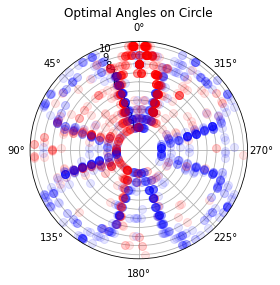

In [9]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if q.q_error < 0.1:
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)


In [10]:
print(len(angles_list))

99


In [6]:
angles_list_2 = []
p = 8
bds = [(0.0, np.pi/2)] * p + [(0.0,  np.pi/2)] * p
for i in tqdm(range(100)):
    q = QAOA(p, hamiltonian)
    q.run_heuristic_LW(bds=bds)
    if q.q_error < 0.1:
        angles_list_2.append(q.opt_angles)



100%|██████████| 100/100 [10:25<00:00,  6.25s/it]


NameError: name 'plot_multiple_angles_on_circle' is not defined

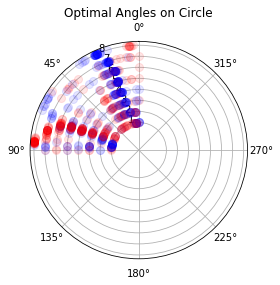

In [8]:
plot_multiple_angles_on_circle(angles_list_2)

In [19]:
mins = 1
mins_angles = []
for i in angles_list_2:
    en = q.expectation(i)
    if en < mins:
        mins = en
        mins_angles = i

In [63]:
mins_angles, mins

(array([0.09585544, 0.22536383, 0.26541474, 0.28498775, 0.2886315 ,
        0.29465493, 0.3621422 , 0.434874  , 1.03004972, 1.19498415,
        1.24603693, 1.24741874, 1.26699171, 1.32087719, 1.41084545,
        1.50594797]), -7.98650282814233)

In [16]:
real_min = np.array([2,1,2,2,2,2,1,2])/8 * np.pi
real_min

array([0.78539816, 0.39269908, 0.78539816, 0.78539816, 0.78539816,
       0.78539816, 0.39269908, 0.78539816])

In [17]:
q = QAOA(4, hamiltonian)

In [18]:
q.expectation(real_min)

-7.999999999999994

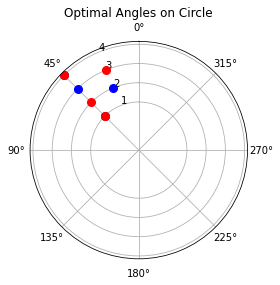

In [23]:
plot_multiple_angles_on_circle([real_min], alpha=1)

In [48]:
angles_list_3 = []
p = 8
bds = [(0.0, np.pi/2)] * p + [(0.0, np.pi/2)] * p
for i in tqdm(range(100)):
    q = QAOA(p, hamiltonian)
    q.run_heuristic_LW(bds=bds)
    if q.q_error < 0.1:
        angles_list_3.append(q.opt_angles)

100%|██████████| 100/100 [11:38<00:00,  6.99s/it]


In [49]:
len(angles_list_3)

38

In [50]:
q.q_error

0.024023363152988253

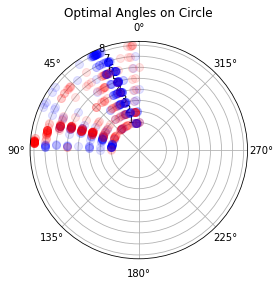

In [51]:
plot_multiple_angles_on_circle(angles_list_3)

In [82]:
import numpy as np

def invert(angles):
    if isinstance(angles, list):
        return angles[len(angles)//2:][::-1] + angles[:len(angles)//2][::-1]
    elif isinstance(angles, np.ndarray):
        return np.concatenate((angles[len(angles)//2:][::-1], angles[:len(angles)//2][::-1]))
    else:
        raise ValueError("Unsupported data type. Expected list or ndarray.")


In [83]:
q.expectation(real_min), q.expectation(invert(real_min.tolist()))

(-7.9999999999999885, -7.9999999999999885)

In [84]:
q.expectation(mins_angles), q.expectation(invert(mins_angles.tolist()))

(-7.98650282814233, -7.4053420567988475)

In [88]:
avg_angles = (mins_angles  + invert(mins_angles))/2

In [89]:
q.expectation(avg_angles)

-0.03469379986814414

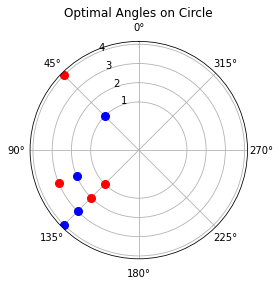

-7.9999999999999885


In [94]:
x = real_min
plot_multiple_angles_on_circle([x], alpha=1)
print(q.expectation(x))

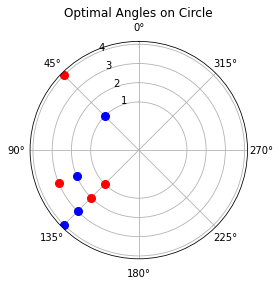

-7.9999999999999885


In [95]:
x = invert(real_min)
plot_multiple_angles_on_circle([x], alpha=1)
print(q.expectation(x))

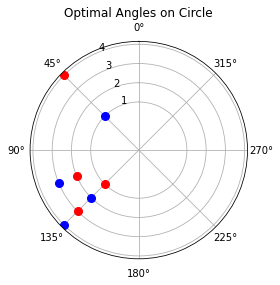

-1.000000000000007


In [96]:
x = np.array([2,6,5,6,6,5,6,2])/8 * np.pi
plot_multiple_angles_on_circle([x], alpha=1)
print(q.expectation(x))

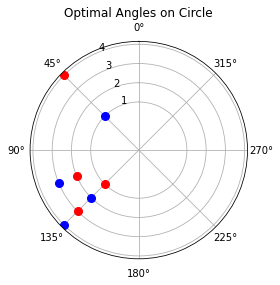

-1.000000000000007


In [97]:
x = invert(np.array([2,6,5,6,6,5,6,2])/8 * np.pi)
plot_multiple_angles_on_circle([x], alpha=1)
print(q.expectation(x))

In [120]:
from scipy.optimize import minimize

def make_objective(q):
    def objective(angles):
        return q.expectation(angles)
    return objective

def make_constraint(objective):
    def constraint(angles):
        return objective(angles) - objective(invert(angles))
    return constraint

def optimize_angles(q, initial_angles):
    len_angles = len(initial_angles)
    objective = make_objective(q)
    # Define the optimization problem
    constraint = make_constraint(objective)
    bounds = [(0, np.pi)] * len_angles  # Boundaries from 0 to pi for each angle
    opt_result = minimize(objective, initial_angles, constraints={'type': 'eq', 'fun': constraint}, bounds=bounds)
    
#     return opt_result.x
    if opt_result.success:
        return opt_result.x
    else:
        return []


In [121]:
sym_angles = []
for i in tqdm(range(100)):
    initial_angles = np.random.rand(10)  # Example initial angles
    optimized_angles = optimize_angles(q, initial_angles)
    if len(optimized_angles) != 0:
        sym_angles.append(optimized_angles)

100%|██████████| 100/100 [03:15<00:00,  1.95s/it]


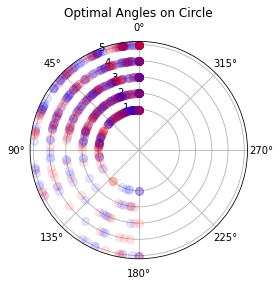

In [122]:
plot_multiple_angles_on_circle(sym_angles)

In [154]:
from scipy.optimize import minimize

def make_objective(q):
    def objective(gamma):
#         print(np.array(gamma)[::-1])
        angles =  np.concatenate((np.array(gamma), np.array(gamma)[::-1]))
        return q.expectation(angles)
    return objective

def optimize_angles(q, initial_angles):
    len_angles = len(initial_angles)
    objective = make_objective(q)
    bounds = [(0, np.pi)] * len_angles  # Boundaries from 0 to pi for each angle
    opt_result = minimize(objective, initial_angles, bounds=bounds)
    
#     return opt_result.x
    if opt_result.success:
        return opt_result.x
    else:
        return []


In [162]:
sym_angles = []
for i in tqdm(range(100)):
    initial_angles = np.random.rand(5)  # Example initial angles
    optimized_angles = optimize_angles(q, initial_angles)
    if len(optimized_angles) != 0:
        sym_angles.append(optimized_angles)

100%|██████████| 100/100 [00:07<00:00, 13.18it/s]


In [163]:

for i in range(len(sym_angles)):
    sym_angles[i] = np.concatenate((sym_angles[i], sym_angles[i][::-1]))

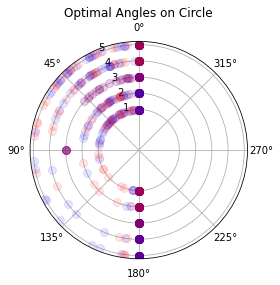

In [164]:
plot_multiple_angles_on_circle(sym_angles)

In [165]:
from scipy.optimize import minimize

def make_objective(q):
    def objective(gamma):
#         print(np.array(gamma)[::-1])
        angles =  np.concatenate((np.array(gamma), np.array(gamma)[::-1]))
        return q.expectation(angles)
    return objective

def optimize_angles(q, initial_angles):
    len_angles = len(initial_angles)
    objective = make_objective(q)
    bounds = [(0, np.pi/2)] * len_angles  # Boundaries from 0 to pi for each angle
    opt_result = minimize(objective, initial_angles, bounds=bounds)
    
#     return opt_result.x
    if opt_result.success:
        return opt_result.x
    else:
        return []


In [166]:
sym_angles = []
for i in tqdm(range(100)):
    initial_angles = np.random.rand(5)  # Example initial angles
    optimized_angles = optimize_angles(q, initial_angles)
    if len(optimized_angles) != 0:
        sym_angles.append(optimized_angles)

100%|██████████| 100/100 [00:05<00:00, 18.01it/s]


In [167]:

for i in range(len(sym_angles)):
    sym_angles[i] = np.concatenate((sym_angles[i], sym_angles[i][::-1]))

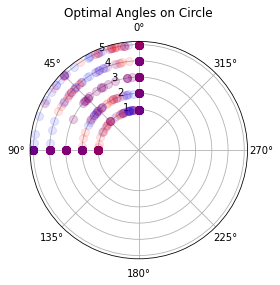

In [168]:
plot_multiple_angles_on_circle(sym_angles)

In [169]:
for i in sym_angles:
    print(q.expectation(i))

1.6332384033187607e-29
1.6332384033187605e-29
7.258837348083387e-30
-3.0679565313518102
1.8147093370208477e-30
4.5367733425521126e-29
2.903534939233354e-29
7.25883734808339e-30
2.903534939233354e-29
0.0
1.8147093370208477e-30
1.6332384033187607e-29
-3.6392909082382587
-2.0605506980722392
7.258837348083385e-30
7.25883734808339e-30
1.6332384033187607e-29
-5.288596142251438
7.258837348083388e-30
-8.881784197001252e-16
7.258837348083388e-30
7.258837348083388e-30
1.6332384033187607e-29
1.6332384033187607e-29
1.8147093370208477e-30
7.25883734808339e-30
1.6332384033187607e-29
1.8147093370208477e-30
1.6332384033187602e-29
1.8147093370208473e-30
1.8147093370208477e-30
2.903534939233354e-29
-4.923644921099118
1.6332384033187607e-29
1.1102230246251565e-16
-3.5967071556332053
1.6332384033187602e-29
7.258837348083388e-30
1.6332384033187624e-29
4.5367733425521126e-29
1.6332384033187607e-29
-1.4730732018928332
-2.1325637358727265
-1.991742080113102
1.8147093370208477e-30
2.903534939233354e-29
7.25883

100%|██████████| 100/100 [29:58<00:00, 17.98s/it]


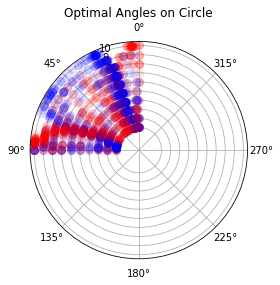

In [52]:
angles_list_4 = []
p = 10
bds = [(0.0, np.pi/2)] * p + [(0.0, np.pi/2)] * p
for i in tqdm(range(100)):
    q = QAOA(p, hamiltonian)
    q.run_heuristic_LW(bds=bds)
    if q.q_error < 0.1:
        angles_list_4.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list_4)

In [53]:
np.array(angles_list_4)/np.pi

array([[0.46483936, 0.41674775, 0.40288398, ..., 0.11926304, 0.02820212,
        0.45095144],
       [0.02889177, 0.07008373, 0.10283201, ..., 0.30664056, 0.45013073,
        0.4790926 ],
       [0.        , 0.03384383, 0.07312256, ..., 0.42243755, 0.44665269,
        0.47532927],
       ...,
       [0.46942485, 0.42655792, 0.38795591, ..., 0.42440564, 0.47207262,
        0.01947038],
       [0.05287642, 0.47646291, 0.10652047, ..., 0.48254867, 0.0709834 ,
        0.02056387],
       [0.46828208, 0.4148918 , 0.10490669, ..., 0.10318699, 0.33581642,
        0.48106134]])

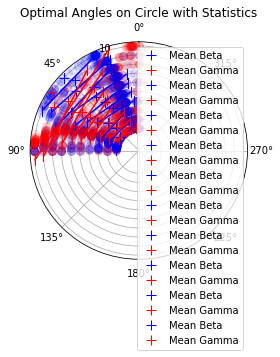

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_multiple_angles_on_circle_with_stats(angles_list, alpha=0.1):
    """
    Plot optimal angles as dots on a circle for betas and gammas with different colors for multiple angle arrays,
    along with statistics such as mean and standard deviation.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.

    Returns:
    - None
    """
    num_betas = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    num_runs = len(angles_list)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('N')
    ax.set_aspect('equal')

    radius = [0.5 + 0.2*i for i in range(num_betas)]
    all_betas = np.array([angle[:num_betas] for angle in angles_list])
    all_gammas = np.array([angle[num_betas:] for angle in angles_list])

    # Plot optimal angles
    for angles in angles_list:
        betas = angles[:num_betas]
        gammas = angles[num_betas:]
        for i, r in enumerate(radius):
            # Plot betas with reduced transparency
            ax.plot(betas[i], r, 'bo', markersize=8, alpha=alpha)

            # Plot gammas with reduced transparency
            ax.plot(gammas[i], r, 'ro', markersize=8, alpha=alpha)

    # Compute statistics
    mean_betas = np.mean(all_betas, axis=0)
    std_betas = np.std(all_betas, axis=0)
    mean_gammas = np.mean(all_gammas, axis=0)
    std_gammas = np.std(all_gammas, axis=0)

    # Plot statistics
    for i, r in enumerate(radius):
        # Plot mean betas
        ax.plot(mean_betas[i], r, 'b+', markersize=10, )
        # Plot error bars for betas
        ax.errorbar(mean_betas[i], r, xerr=std_betas[i], fmt='none', ecolor='b', capsize=5)

        # Plot mean gammas
        ax.plot(mean_gammas[i], r, 'r+', markersize=10, )
        # Plot error bars for gammas
        ax.errorbar(mean_gammas[i], r, xerr=std_gammas[i], fmt='none', ecolor='r', capsize=5)

    plt.title("Optimal Angles on Circle with Statistics")
    ax.set_yticks([0.5 + 0.2*i for i in range(num_betas)])
    ax.set_yticklabels([i+1 for i in range(num_betas)])
    plt.legend()
    plt.show()

plot_multiple_angles_on_circle_with_stats(angles_list_4)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


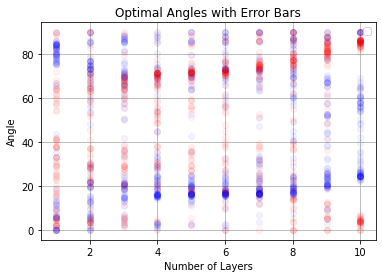

In [62]:


def plot_angles_with_errorbars(angles_list, alpha_mean=1, alpha_all=0.05):
    """
    Plot optimal angles with error bars representing the standard deviation for each layer.

    Args:
    - angles_list (list of arrays): List of optimal angle arrays for betas and gammas.
    - alpha_mean (float): Transparency value for mean points.
    - alpha_all (float): Transparency value for all points.

    Returns:
    - None
    """
    num_layers = len(angles_list[0]) // 2  # Assuming all arrays have the same length
    all_betas = 57.3*np.array([angle[:num_layers] for angle in angles_list])
    all_gammas = 57.3*np.array([angle[num_layers:] for angle in angles_list])

    # Compute mean and standard deviation
    mean_betas = np.mean(all_betas, axis=0)
    std_betas = np.std(all_betas, axis=0)
    mean_gammas = np.mean(all_gammas, axis=0)
    std_gammas = np.std(all_gammas, axis=0)

    # Plot all betas and gammas with reduced transparency
    for betas, gammas in zip(all_betas, all_gammas):
        plt.plot(range(1, num_layers + 1), betas, 'bo', alpha=alpha_all)
        plt.plot(range(1, num_layers + 1), gammas, 'ro', alpha=alpha_all)

    # Plot mean betas and gammas with full transparency
#     plt.errorbar(range(1, num_layers + 1), mean_betas, yerr=std_betas, fmt='bo', label='Beta', alpha=alpha_mean)
#     plt.errorbar(range(1, num_layers + 1), mean_gammas, yerr=std_gammas, fmt='ro', label='Gamma', alpha=alpha_mean)

    plt.xlabel('Number of Layers')
    plt.ylabel('Angle')
    plt.title('Optimal Angles with Error Bars')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_angles_with_errorbars(angles_list_4)

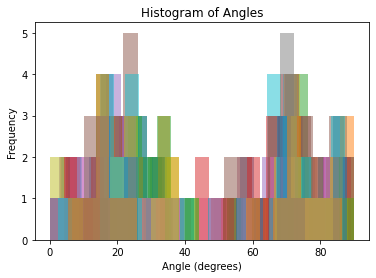

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_angle_histogram(angles_list, bins=20, alpha=0.5):
    """
    Plot histograms of angles.

    Args:
    - angles_list (list of arrays): List of arrays containing angles.
    - bins (int): Number of bins for the histogram.
    - alpha (float): Transparency of the bars.

    Returns:
    - None
    """
    num_runs = len(angles_list)
    num_angles = len(angles_list[0])
    fig, ax = plt.subplots()

    for angles in angles_list:
        # Convert angles to degrees for better visualization
        angles_deg = np.degrees(angles)
        ax.hist(angles_deg, bins=bins, alpha=alpha)

    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('Frequency')
    ax.set_title('Histogram of Angles')
#     ax.legend([f'Run {i+1}' for i in range(num_runs)])

    plt.show()

# Example usage:
# angles_list = [[0.1, 0.2, 0.3, 0.4, 0.5], [0.2, 0.3, 0.4, 0.5, 0.6]]
plot_angle_histogram(angles_list_2)


In [18]:
180/8

22.5

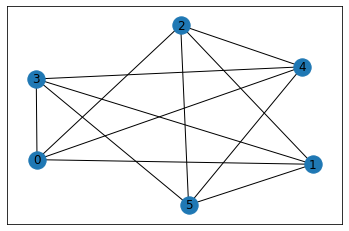

In [18]:
n = 6  # Number of nodes
d = 4  # Degree of each node
G = nx.random_regular_graph(d, n)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
nx.draw_networkx(G)
hamiltonian = Graph_to_Hamiltonian(adj_matrix)



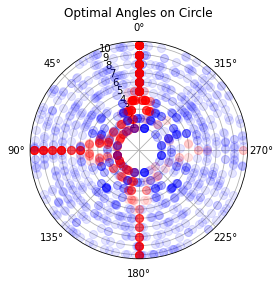

In [19]:
angles_list = []
for i in range(100):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)
print(len(angles_list))

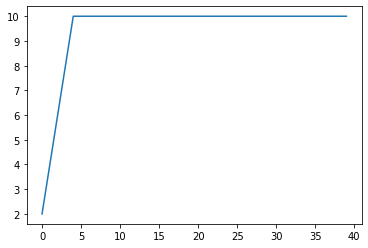

In [20]:
rank = []
for p in range(1,41):
    q = QAOA(p, hamiltonian)
    buf = 0
    for _ in range(10):
        buf += np.linalg.matrix_rank(q.qaoa_qfi_matrix(np.random.rand(2*p)*np.pi))
    rank.append(buf/10)
plt.plot(rank)

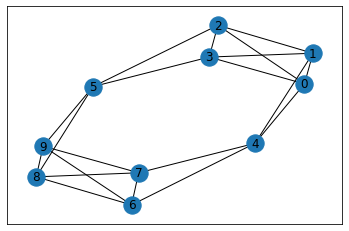

In [113]:
edges = [[0, 1],
 [0, 2],
 [0, 3],
 [0, 4],
 [1, 0],
 [1, 2],
 [1, 3],
 [1, 4],
 [2, 0],
 [2, 1],
 [2, 3],
 [2, 5],
 [3, 0],
 [3, 1],
 [3, 2],
 [3, 5],
 [4, 0],
 [4, 1],
 [4, 6],
 [4, 7],
 [5, 2],
 [5, 3],
 [5, 8],
 [5, 9],
 [6, 4],
 [6, 7],
 [6, 8],
 [6, 9],
 [7, 4],
 [7, 6],
 [7, 8],
 [7, 9],
 [8, 5],
 [8, 6],
 [8, 7],
 [8, 9],
 [9, 5],
 [9, 6],
 [9, 7],
 [9, 8]]

G = nx.from_edgelist(edges)
nx.draw_networkx(G)
adj_matrix = nx.adjacency_matrix(G).todense().tolist()
hamiltonian = Graph_to_Hamiltonian(adj_matrix)

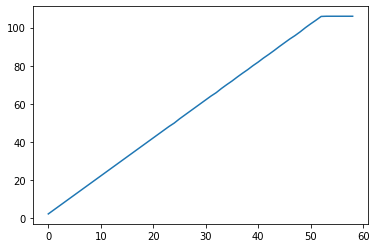

In [114]:
rank = []
for p in tqdm(range(1,60)):
    q = QAOA(p, hamiltonian)
    buf = 0
    for _ in range(10):
        buf += np.linalg.matrix_rank(q.qaoa_qfi_matrix(np.random.rand(2*p)*np.pi))
    rank.append(buf/10)
plt.plot(rank)

In [ ]:
angles_list = []
for i in tqdm(range(100)):
    q = QAOA(10, hamiltonian)
    q.run_heuristic_LW()
    if np.allclose(q.q_error,0):
        angles_list.append(q.opt_angles)
plot_multiple_angles_on_circle(angles_list)
